# ⚗️ Darkroom Calculator & Kinetics Simulator

### Welcome, Darkroom Chemists!
Professional film development requires absolute precision. If you use too much developing agent, your negatives will turn completely black. If you use too little, they will be blank. 

In this notebook, we will build a **Stoichiometry Calculator** to perfectly scale the famous Kodak D-76 recipe for any size darkroom tank. Then, we will simulate the **Chemical Kinetics** of the Oxidation-Reduction (Redox) reaction to see how fast the silver forms.

**Teacher Instructions:** Run the cells below to calculate chemical masses and graph the rate of the development reaction.

In [1]:
def darkroom_stoichiometry(target_volume_ml=250):
    """
    Calculates the exact mass and moles needed to mix a custom batch of D-76 Developer.
    Base recipe is for 1000ml (1 Liter).
    """
    # Base D-76 Recipe (grams per 1000ml)
    base_recipe = {
        "Metol": 2.0,
        "Sodium Sulfite": 100.0,
        "Hydroquinone": 5.0,
        "Borax": 2.0
    }
    
    # Molar Masses (g/mol)
    molar_masses = {
        "Metol": 344.38,
        "Sodium Sulfite": 126.04,
        "Hydroquinone": 110.11,
        "Borax": 381.37
    }
    
    scale_factor = target_volume_ml / 1000.0
    
    print(f"🧪 RECIPE FOR {target_volume_ml}ml of KODAK D-76")
    print("-" * 40)
    print("Start with 75% of your total volume as warm distilled water (50°C).")
    print("Dissolve in this exact order:")
    
    for chemical, base_mass in base_recipe.items():
        # Calculate scaled mass
        scaled_mass = base_mass * scale_factor
        # Calculate moles
        moles = scaled_mass / molar_masses[chemical]
        
        print(f"  -> {chemical}: {scaled_mass:.2f}g ({moles:.4f} moles)")
        
    print("-" * 40)
    print(f"Finally, top off with cold distilled water to reach exactly {target_volume_ml}ml.")

# Run the calculator! 
# Change the volume to fit your school's development tank (e.g., 250, 500, or 1000)
darkroom_stoichiometry(target_volume_ml=250)

🧪 RECIPE FOR 250ml of KODAK D-76
----------------------------------------
Start with 75% of your total volume as warm distilled water (50°C).
Dissolve in this exact order:
  -> Metol: 0.50g (0.0015 moles)
  -> Sodium Sulfite: 25.00g (0.1983 moles)
  -> Hydroquinone: 1.25g (0.0114 moles)
  -> Borax: 0.50g (0.0013 moles)
----------------------------------------
Finally, top off with cold distilled water to reach exactly 250ml.


### 📉 Chemical Kinetics: The Rate of Reduction
Now that we have mixed our developer, let's pour it into the tank. 

The moment the Hydroquinone touches the Silver Bromide, a Redox reaction begins. 
* The Silver ions ($Ag^+$) are reduced into metallic Silver ($Ag$).
* The Hydroquinone is oxidized. 

But this doesn't happen instantly. It follows a mathematical curve. As the developer gets used up (oxidized), the reaction slows down. Let's graph it!

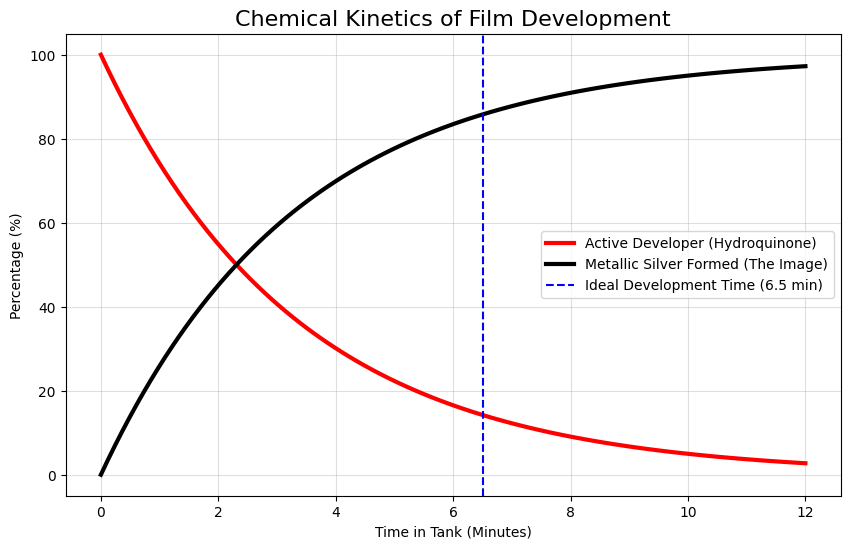

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_redox_kinetics(development_time_mins=10):
    """
    Simulates the concentration of reactants and products during film development.
    """
    # Create an array of time points
    time = np.linspace(0, development_time_mins, 100)
    
    # Simulate first-order kinetics
    # Concentration of active developer decreases exponentially
    k_dev = 0.3 # Rate constant
    developer_concentration = 100 * np.exp(-k_dev * time)
    
    # Concentration of Metallic Silver increases as developer is used
    # Assuming a 1:1 relationship for simplicity of visualization
    silver_metal = 100 * (1 - np.exp(-k_dev * time))
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(time, developer_concentration, 'r-', linewidth=3, label="Active Developer (Hydroquinone)")
    plt.plot(time, silver_metal, 'k-', linewidth=3, label="Metallic Silver Formed (The Image)")
    
    # Mark the ideal pulling time (e.g., 6.5 minutes for D-76)
    ideal_time = 6.5
    plt.axvline(ideal_time, color='b', linestyle='--', label=f"Ideal Development Time ({ideal_time} min)")
    
    plt.title("Chemical Kinetics of Film Development", fontsize=16)
    plt.xlabel("Time in Tank (Minutes)")
    plt.ylabel("Percentage (%)")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()

# Run the kinetics simulator!
plot_redox_kinetics(development_time_mins=12)

### 🔍 Analysis of the Curve
Look at the black line representing the Silver Image. 
1. **The Beginning:** It shoots up very quickly. The fresh developer attacks the latent image aggressively.
2. **The Plateau:** As time goes on, the line flattens out. Most of the latent image has already been reduced to silver, and the developer is starting to run out of electrons to give. 
3. **The Danger Zone:** If you leave the film in past the "Ideal Time" (the blue dotted line), the developer will start forcing electrons onto unexposed crystals, causing chemical fog and ruining the picture!

This curve proves why darkroom timers must be so precise. You are controlling a live chemical reaction!